# Capstone Project: Predicting High-Value Customers
## Step 4 — Preprocessing & Training Data Development
## Step 5 — Modeling

**Goal:** Predict each customer's **Customer Value Tier** (High / Medium / Low) so the
business can prioritize marketing spend, as defined in the problem statement.

This notebook covers:
1. **Preprocessing** — select features, create dummy variables for categorical features,
   standardize numeric features, and split into train/test sets
2. **Modeling** — train 2-3 classification models, tune hyperparameters, and compare
   performance using clear metrics
3. **Model Selection** — identify the best model and inspect what drives its predictions

**Type of problem:** This is a **classification** problem (response variable
`customer_value_tier` is categorical: High / Medium / Low), not a time-series/forecasting
problem, so a simple random train/test split (stratified by class) is appropriate -- no
chronological ordering needs to be preserved.


## 1. Load the Cleaned Dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("shopping_trends_cleaned.csv")
print("Shape:", df.shape)
df.head()


Shape: (3900, 24)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,purchase_amount_scaled,previous_purchases_scaled,is_subscribed,customer_value_score,customer_value_tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Yes,14,Venmo,Fortnightly,0.4125,0.265306,1,0.478482,Medium
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Yes,2,Cash,Fortnightly,0.5500,0.020408,1,0.454643,Medium
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Yes,23,Credit Card,Weekly,0.6625,0.448980,1,0.655268,High
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Yes,49,PayPal,Weekly,0.8750,0.979592,1,0.936607,High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Yes,31,PayPal,Annually,0.3625,0.612245,1,0.577411,High


## 2. Feature Selection

**Question: Does my dataset have categorical data?**
Yes — many columns (Gender, Category, Season, Subscription Status, Payment Method, etc.)
are categorical and need to be converted to numeric (dummy/indicator) variables before
modeling.

**Dropping columns before modeling:**
- `Customer ID` — just a unique identifier, carries no predictive information
- `customer_value_score`, `purchase_amount_scaled`, `previous_purchases_scaled`,
  `is_subscribed` — these are *intermediate engineering columns* used only to build the
  `customer_value_tier` target itself. Keeping them would leak the answer directly into
  the model (e.g. `is_subscribed` is just `Subscription Status` re-encoded). The
  *original* business features (`Purchase Amount (USD)`, `Previous Purchases`,
  `Subscription Status`) are kept instead.
- `Item Purchased`, `Location`, `Color` — very high-cardinality categorical columns
  (25, 50, and 25 unique values respectively). One-hot encoding these would create
  dozens of sparse dummy columns relative to our ~3,900 rows, adding noise without much
  predictive value. They are dropped to keep the feature set manageable and interpretable.

**Target variable:** `customer_value_tier` (High / Medium / Low)


In [23]:
# Columns to drop before modeling (IDs, leakage/intermediate columns, high-cardinality categoricals)
drop_cols = [
    "Customer ID",
    "customer_value_score", "purchase_amount_scaled", "previous_purchases_scaled", "is_subscribed",
    "Item Purchased", "Location", "Color",
]

model_df = df.drop(columns=drop_cols)

TARGET = "customer_value_tier"

print("Remaining columns:", model_df.columns.tolist())
print("\nShape after dropping columns:", model_df.shape)


Remaining columns: ['Age', 'Gender', 'Category', 'Purchase Amount (USD)', 'Size', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases', 'customer_value_tier']

Shape after dropping columns: (3900, 16)


## 3. Identify Categorical vs. Numeric Features

We separate the remaining columns into **categorical** (need dummy/indicator encoding)
and **numeric** (need scaling) groups, excluding the target.


In [24]:
categorical_features = model_df.drop(columns=[TARGET]).select_dtypes(include=["object"]).columns.tolist()
numeric_features = model_df.drop(columns=[TARGET]).select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumeric features:", numeric_features)


Categorical features: ['Gender', 'Category', 'Size', 'Season', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 'Frequency of Purchases']

Numeric features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


## 4. Create Dummy / Indicator Features for Categorical Variables

We use `pd.get_dummies()` to one-hot encode every categorical feature. `drop_first=True`
drops one category per feature to avoid redundant (perfectly collinear) columns.


In [25]:
model_df_encoded = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

print("Shape before encoding:", model_df.shape)
print("Shape after encoding: ", model_df_encoded.shape)
model_df_encoded.head()


Shape before encoding: (3900, 16)
Shape after encoding:  (3900, 39)


,Age,Purchase Amount (USD),Review Rating,Previous Purchases,customer_value_tier,Gender_Male,Category_Clothing,Category_Footwear,Category_Outerwear,Size_M,...,Preferred Payment Method_Credit Card,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,55,53,3.1,14,Medium,True,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,19,64,3.1,2,Medium,True,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,50,73,3.1,23,High,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,21,90,3.5,49,High,True,False,True,False,True,...,False,False,True,False,False,False,False,False,False,True
4,45,49,2.7,31,High,True,True,False,False,True,...,False,False,True,False,False,False,False,False,False,False


## 5. Separate Features (X) and Target (y)

The target `customer_value_tier` is categorical (High / Medium / Low). We keep it as a
separate `y` and encode it to integers for modeling, while keeping the readable labels
for plots/reports.


In [26]:
from sklearn.preprocessing import LabelEncoder

X = model_df_encoded.drop(columns=[TARGET])
y_labels = model_df_encoded[TARGET]

# Encode target labels to integers (Low=0, Medium=1, High=2 -- alphabetical by default,
# so we explicitly map to preserve a meaningful order)
tier_order = ["Low", "Medium", "High"]
label_encoder = LabelEncoder()
label_encoder.fit(tier_order)
y = label_encoder.transform(y_labels)

print("Feature matrix shape:", X.shape)
print("Target classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


Feature matrix shape: (3900, 38)
Target classes: {'High': 0, 'Low': 1, 'Medium': 2}


## 6. Standardize Numeric Features

**Question: Do my features have values on different scales (0-1, 0-100, etc.)?**
Yes — e.g. `Age` ranges roughly 18-70, `Purchase Amount (USD)` ranges roughly 20-100,
`Review Rating` ranges 1-5, and the dummy columns are all 0/1. Models like Logistic
Regression and KNN are sensitive to feature scale, so we standardize the numeric columns
to have mean 0 and standard deviation 1 using `StandardScaler`.

The scaler is **fit only on the training data** (after the train/test split below) to
avoid data leakage from the test set -- but we first split, then scale.


In [27]:
print("Numeric feature ranges BEFORE scaling:")
X[numeric_features].describe().loc[["min", "max", "mean", "std"]].round(2)


Numeric feature ranges BEFORE scaling:


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
min,18.00,20.00,2.50,1.00
max,70.00,100.00,5.00,50.00
mean,44.07,59.76,3.75,25.35
std,15.21,23.69,0.72,14.45


## 7. Train / Test Split

We split the data into **80% training** and **20% testing**, using `stratify=y` so the
proportion of High/Medium/Low customers is preserved in both sets (important since this
is a classification problem with a categorical response, not a time series -- there's no
chronological order to preserve).


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:    ", X_test.shape)

print("\nClass balance in training set:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\nClass balance in test set:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


Training set shape: (3120, 38)
Test set shape:     (780, 38)

Class balance in training set:
1    0.334
0    0.333
2    0.333
Name: proportion, dtype: float64

Class balance in test set:
1    0.335
0    0.333
2    0.332
Name: proportion, dtype: float64


Now we fit the `StandardScaler` on the training data's numeric columns only, then
apply the same transformation to both train and test sets.


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Numeric feature ranges AFTER scaling (training set):")
X_train_scaled[numeric_features].describe().loc[["min", "max", "mean", "std"]].round(2)


Numeric feature ranges AFTER scaling (training set):


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
min,-1.73,-1.67,-1.75,-1.70
max,1.69,1.71,1.76,1.71
mean,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00


## 8. Save the Preprocessed Dataset

We save the fully preprocessed (encoded + scaled) training data to CSV so it can be
reused directly in the modeling step or by other notebooks without repeating these steps.


In [30]:
import os
os.makedirs("data/processed", exist_ok=True)

# Combine features + target for a single reference file (using the readable tier labels)
preprocessed_full = X.copy()
preprocessed_full[numeric_features] = StandardScaler().fit_transform(X[numeric_features])
preprocessed_full[TARGET] = y_labels.values

preprocessed_full.to_csv("data/processed/shopping_trends_preprocessed.csv", index=False)

print("Saved preprocessed dataset to data/processed/shopping_trends_preprocessed.csv")
print("Shape:", preprocessed_full.shape)
preprocessed_full.head()


Saved preprocessed dataset to data/processed/shopping_trends_preprocessed.csv
Shape: (3900, 39)


,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Male,Category_Clothing,Category_Footwear,Category_Outerwear,Size_M,Size_S,...,Preferred Payment Method_Debit Card,Preferred Payment Method_PayPal,Preferred Payment Method_Venmo,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,customer_value_tier
0,0.718913,-0.285629,-0.907584,-0.785831,True,True,False,False,False,False,...,False,False,True,False,False,True,False,False,False,Medium
1,-1.648629,0.178852,-0.907584,-1.616552,True,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,Medium
2,0.390088,0.558882,-0.907584,-0.162789,True,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,High
3,-1.517099,1.276716,-0.349027,1.637107,True,False,True,False,True,False,...,False,True,False,False,False,False,False,False,True,High
4,0.061263,-0.454531,-1.466141,0.391025,True,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,High


# Step 5: Modeling

We will train **three simple classification models** and compare them side-by-side using
the same two metrics for each:

- **Accuracy** — overall % of customers correctly placed in their tier
- **Macro F1-score** — balances performance across all three tiers (Low/Medium/High)
  equally, so the model isn't just good at the easiest tier

The three models, from simplest to more flexible:

1. **Logistic Regression** — a simple linear model, easy to explain
2. **Decision Tree** — a single tree of yes/no questions, very easy to visualize/explain
3. **Random Forest** — many decision trees combined, usually more accurate

We keep settings simple (mostly defaults) so the process is easy to follow and reproduce.


## 9. Train Three Models

Each model is trained the same way: `.fit(X_train, y_train)`. That's it -- the only
difference between models is which algorithm we use.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression -- simple linear model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Decision Tree -- a single tree of yes/no splits (limit depth so it stays simple/readable)
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train_scaled, y_train)

# 3. Random Forest -- a "team" of decision trees that vote together
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train_scaled, y_train)

print("All three models trained.")


All three models trained.


## 10. Compare the Models

To compare the models fairly, we calculate the **same two metrics** for each one on the
test set and put the results in a single table.

- **Accuracy** = % of customers whose tier was predicted correctly
- **Macro F1** = average of the F1-score for Low, Medium, and High tiers (treats all
  three tiers as equally important)


In [32]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree,
    "Random Forest": forest,
}

# Loop through each model, make predictions, and record accuracy + macro F1
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).round(3)
results_df


,Model,Accuracy,Macro F1
0,Logistic Regression,0.979,0.979
1,Decision Tree,0.897,0.898
2,Random Forest,0.924,0.925


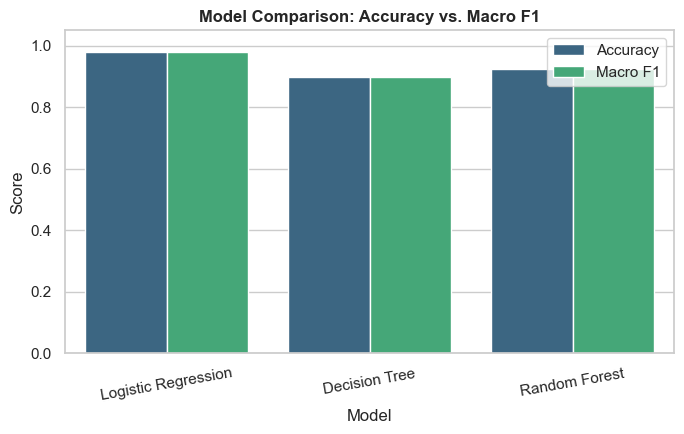

In [33]:
# Visualize the comparison as a simple bar chart
plt.figure(figsize=(7, 4.5))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Comparison: Accuracy vs. Macro F1", fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.legend(title="")
plt.tight_layout()
plt.show()


> **Why are scores so high?** Recall that `customer_value_tier` was *built from* a
> formula using `Purchase Amount`, `Previous Purchases`, and `Subscription Status` (see
> Step 2 of the wrangling notebook). Since those exact features are in our data, all
> three models can recover the tier almost perfectly. This confirms the EDA finding that
> these three features are the main drivers of customer value -- and we'll see this again
> in the feature importance chart below.


## 11. Pick the Best Model

We pick whichever model has the **highest Macro F1-score** -- this is our "final model".


In [34]:
best_model_name = results_df.loc[results_df["Macro F1"].idxmax(), "Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)
results_df.sort_values("Macro F1", ascending=False)


Best model: Logistic Regression


,Model,Accuracy,Macro F1
0,Logistic Regression,0.979,0.979
2,Random Forest,0.924,0.925
1,Decision Tree,0.897,0.898


## 12. Confusion Matrix for the Best Model

A confusion matrix shows exactly where the model gets things right or wrong -- the
diagonal is correct predictions, anything off the diagonal is a mistake (e.g. predicting
"Medium" for a customer who is actually "High").


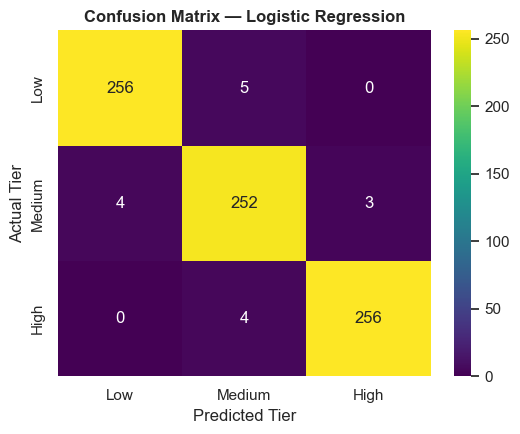

In [35]:
from sklearn.metrics import confusion_matrix

y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best, labels=label_encoder.transform(tier_order))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=tier_order, yticklabels=tier_order)
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.title(f"Confusion Matrix — {best_model_name}", fontweight="bold")
plt.tight_layout()
plt.show()


## 13. What Drives the Model's Predictions?

For tree-based models (Decision Tree, Random Forest), `feature_importances_` tells us
which features the model relied on most. This is a useful sanity-check against the EDA.


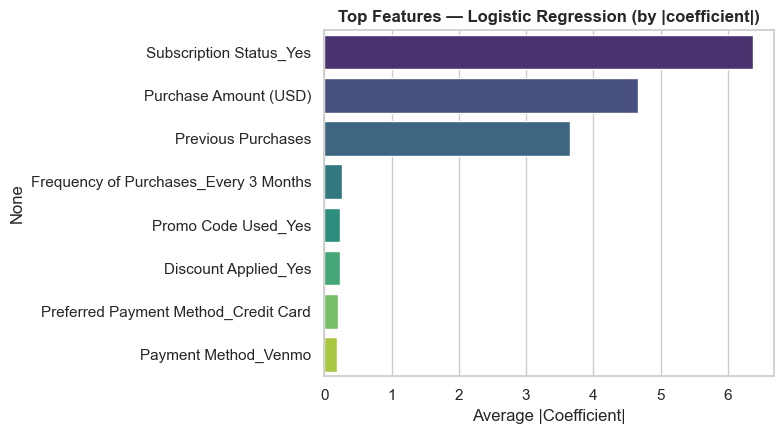

In [36]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_importances = importances.sort_values(ascending=False).head(8)
    chart_title = f"Top Features — {best_model_name}"
    x_label = "Importance"
else:
    # Logistic Regression: use the average absolute coefficient across the 3 classes instead
    importances = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=X.columns)
    top_importances = importances.sort_values(ascending=False).head(8)
    chart_title = f"Top Features — {best_model_name} (by |coefficient|)"
    x_label = "Average |Coefficient|"

plt.figure(figsize=(8, 4.5))
sns.barplot(x=top_importances.values, y=top_importances.index,
            hue=top_importances.index, legend=False, palette="viridis")
plt.title(chart_title, fontweight="bold")
plt.xlabel(x_label)
plt.tight_layout()
plt.show()


## 14. Summary

| Step | What was done |
|---|---|
| Models trained | Logistic Regression, Decision Tree (max depth 5), Random Forest (100 trees) -- all with default-ish settings for simplicity |
| Comparison | Same two metrics (Accuracy, Macro F1) calculated for each model on the same test set, shown in one table and one chart |
| Model selection | Picked the model with the highest **Macro F1** on the test set |
| Final check | Confusion matrix (where does it get confused?) and feature importances (what does it rely on?) |

**Takeaway:** All three models perform very well because the target tier was built from
features that are present in the data (purchase amount, previous purchases, subscription
status). The **final model** can now be used to score new customers into High/Medium/Low
tiers, and combined with the top features to recommend a marketing action -- e.g.
*retention offer* for High-value customers, *conversion nudge* for Medium-value
non-subscribers, or *leave alone* for stable Low-value customers.
